# ADCNN evaluation — catalog-based

Pure analysis of the **pre-generated detection catalogs** (`Evaluation/catalogs/`, from
`make_eval_catalogs`: deployed v7 + focal-cutout-CNN stage-2 (cnn_focal_final.pt), `gate_pmax=0.10`, CNN cut at thr 0.0695). No NN
inference, no training, no test-set threshold tuning. Each σ set: match catalog↔truth
(any-pixel-overlap, fixed `tol_px`, all-trails denominator) → NN object metrics + FP, the
NN vs LSST-stack vs combined comparison, completeness, parameter recovery; plus the cross-σ
completeness overlay (5σ / 5σ+NN / 4σ / 3σ) at the end. LSST-stack recall+FP read from the
stack footprints (`real_labels`) — fast, no inference. (Pixelwise confusion + CNN score sweep omitted.)

In [1]:
import sys
from pathlib import Path
import numpy as np, pandas as pd, h5py, matplotlib.pyplot as plt
REPO = Path('.').resolve(); sys.path.insert(0, str(REPO))
import ADCNN.evaluation.detection as evals
from ADCNN.evaluation.catalog_match import evaluate_catalog, match_pairs
from ADCNN.inference.rf_postproc import DEFAULT_THR

CATALOGS = REPO/'Evaluation/catalogs'; DATA = REPO/'DATA_DIFFIM'; TOL_PX = 20.0
SETS = ['test_5sigma','test_4sigma','test_3sigma']
print(f'CNN cut = 0.0695 (focal cutout CNN, 95% recall op point) | match tol = {TOL_PX}px')

_STACK_FP, _TRUTH = {}, {}
def stack_fp_count(name):
    if name not in _STACK_FP:
        with h5py.File(DATA/name/'test.h5','r') as f:
            rl=f['real_labels']; _STACK_FP[name]=int(sum(int(rl[i].max()) for i in range(rl.shape[0])))
    return _STACK_FP[name]

def evaluate_set(name):
    if name not in _TRUTH:
        cat=pd.read_csv(CATALOGS/f'{name}_detections.csv'); truth=pd.read_csv(DATA/name/'test.csv')
        counts,t=evaluate_catalog(cat,truth,tol_px=TOL_PX); t['stack_detection']=t['stack_detection'].astype(bool)
        _TRUTH[name]=(counts,t,match_pairs(cat,truth,tol_px=TOL_PX),cat)
    return _TRUTH[name]

def show_confusion(counts,title):
    evals.print_confusion_matrix({'TN':pd.NA,'FP':counts['FP'],'FN':counts['FN'],'TP':counts['TP']},title=title)

def compare_methods(name,counts,t):
    nn=t['nn_detected'].astype(bool); st=t['stack_detection']; comb=nn|st; n=len(t); npan=t['image_id'].nunique(); sfp=stack_fp_count(name)
    print(f'\n[{name}] NN vs LSST-stack vs combined (n={n} trails, {npan} panels):')
    print(f'  LSST stack : recall={st.mean():.3f} ({int(st.sum())})   FP={sfp} ({sfp/npan:.1f}/panel)')
    print(f'  v7+CNN     : recall={nn.mean():.3f} ({int(nn.sum())})   FP={counts["FP"]} ({counts["fp_per_panel"]:.1f}/panel)')
    print(f'  combined   : recall={comb.mean():.3f} ({int(comb.sum())})   NN recovers {int((nn&~st).sum())} stack-missed')
    return dict(set=name.replace('test_',''),NN_recall=round(nn.mean(),3),stack_recall=round(st.mean(),3),combined_recall=round(comb.mean(),3),NN_FP=counts['FP'],NN_FP_pp=round(counts['fp_per_panel'],1),stack_FP=sfp,stack_FP_pp=round(sfp/npan,1))

def completeness_overlay(cats, labels, field, bins=12, xlim=None, title=None):
    """Overlay completeness (detected/all per bin) vs `field` for several catalogs; each
    catalog's 'detected' flag is its `stack_detection` column. Same style as the per-set hists."""
    fig, ax = plt.subplots(figsize=(7,4.5))
    for lab, cat in zip(labels, cats):
        det=cat[cat['stack_detection'].astype(bool)]
        vals=cat[field].to_numpy(); vals=vals[np.isfinite(vals)]
        if xlim is not None: vals=vals[(vals>=xlim[0])&(vals<=xlim[1])]
        edges=np.histogram_bin_edges(vals,bins=bins)
        all_i=np.histogram(cat[field],bins=edges)[0]; det_i=np.histogram(det[field],bins=edges)[0]
        ax.stairs(det_i/np.maximum(all_i,1), edges, label=lab)
    ax.set_xlabel(field.replace('_',' ')); ax.set_ylabel('Completeness'); ax.set_title(title or f'Completeness vs {field}'); ax.legend(); ax.grid(True,alpha=0.3); plt.show()

CNN cut = 0.0695 (focal cutout CNN, 95% recall op point) | match tol = 20.0px


## test_5sigma + NN (hero)

test_5sigma + NN — object-level
F1 Score: 0.0357, F2 Score: 0.0843
                 Predicted Negative  Predicted Positive
Actual Negative                <NA>               49341
Actual Positive                  85                 915




[test_5sigma] NN vs LSST-stack vs combined (n=1000 trails, 50 panels):
  LSST stack : recall=0.475 (475)   FP=6405 (128.1/panel)
  v7+CNN     : recall=0.915 (915)   FP=49341 (986.8/panel)
  combined   : recall=0.915 (915)   NN recovers 440 stack-missed


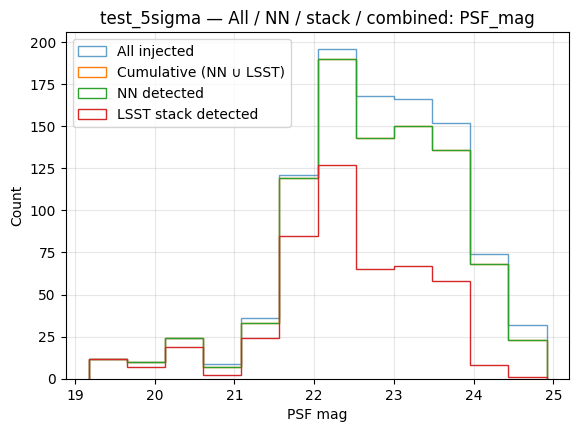

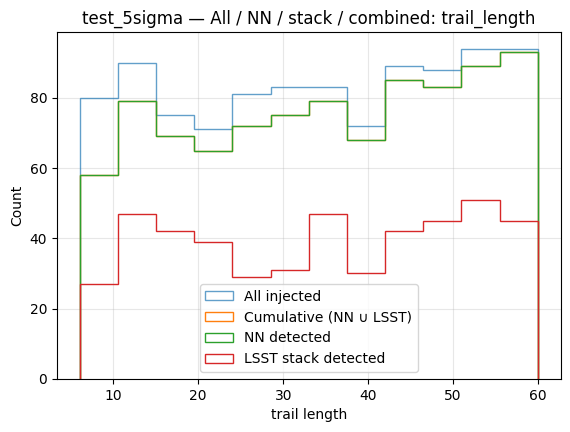

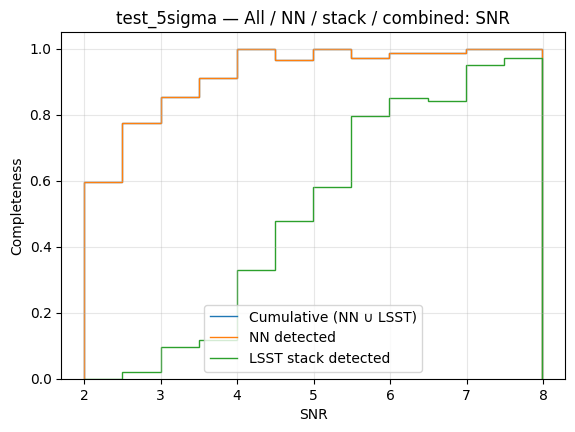

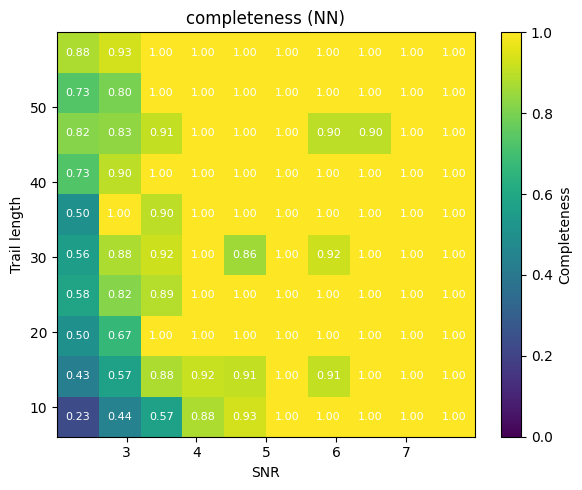

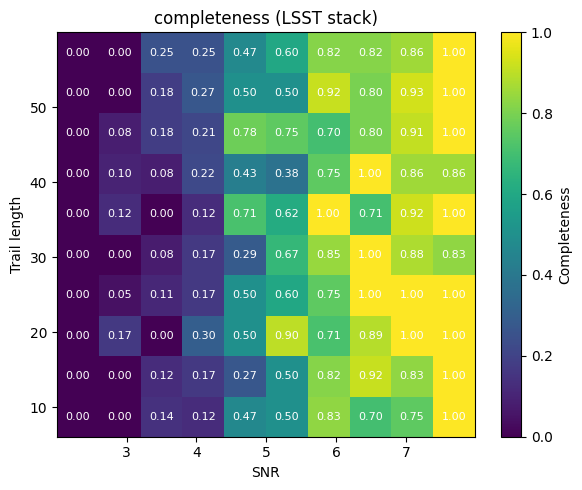

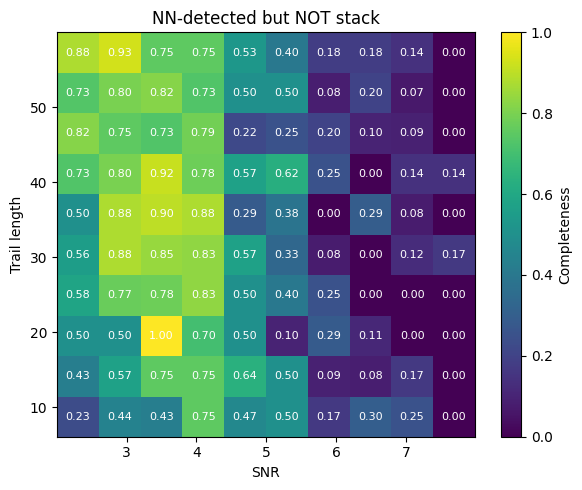

In [2]:
counts, t, pairs, cat = evaluate_set('test_5sigma')
show_confusion(counts, 'test_5sigma + NN — object-level')
row = compare_methods('test_5sigma', counts, t)
for field, kw in [('PSF_mag', {}), ('trail_length', {}), ('SNR', dict(xlim=[0,10], density=True))]:
    evals.plot_detect_hist(t, field, bins=12, title='test_5sigma — All / NN / stack / combined: '+field, **kw); plt.show()
evals.plot_completeness_2d(t, snr_bins=10, trail_bins=10, title='completeness (NN)'); plt.show()
evals.plot_completeness_2d(t, snr_bins=10, trail_bins=10, detected=t['stack_detection'].values, title='completeness (LSST stack)'); plt.show()
evals.plot_completeness_2d(t, snr_bins=10, trail_bins=10, detected=(~t['stack_detection'].values & t['nn_detected'].values.astype(bool)), title='NN-detected but NOT stack'); plt.show()

### Parameter recovery — measured vs true (matched trails): x, y, beta, length

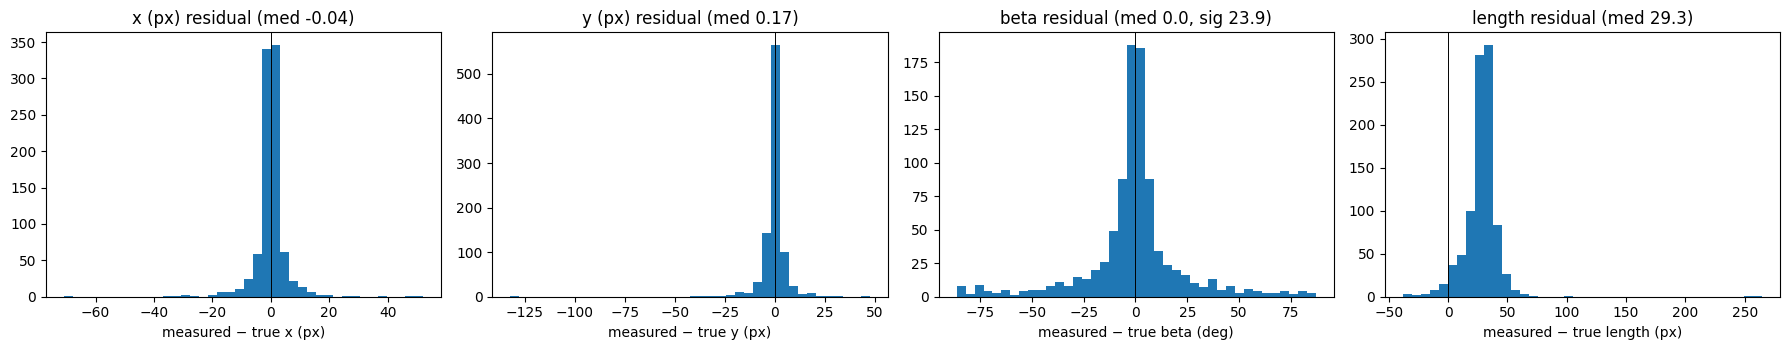

In [3]:
fig, ax = plt.subplots(1, 4, figsize=(18,3.6))
for k,(col,mcol,lab) in enumerate([('x','meas_x','x (px)'),('y','meas_y','y (px)')]):
    d=pairs[mcol]-pairs[col]; ax[k].hist(d,bins=40); ax[k].axvline(0,c='k',lw=.7); ax[k].set_xlabel(f'measured − true {lab}'); ax[k].set_title(f'{lab} residual (med {d.median():.2f})')
db=((pairs.meas_beta-pairs.beta+90)%180)-90; ax[2].hist(db,bins=40); ax[2].axvline(0,c='k',lw=.7); ax[2].set_xlabel('measured − true beta (deg)'); ax[2].set_title(f'beta residual (med {db.median():.1f}, sig {db.std():.1f})')
dl=pairs.meas_length-pairs.trail_length; ax[3].hist(dl,bins=40); ax[3].axvline(0,c='k',lw=.7); ax[3].set_xlabel('measured − true length (px)'); ax[3].set_title(f'length residual (med {dl.median():.1f})')
plt.tight_layout(); plt.show()

## test_4sigma

test_4sigma + NN — object-level
F1 Score: 0.0368, F2 Score: 0.0868
                 Predicted Negative  Predicted Positive
Actual Negative                <NA>               47678
Actual Positive                  87                 913




[test_4sigma] NN vs LSST-stack vs combined (n=1000 trails, 50 panels):
  LSST stack : recall=0.682 (682)   FP=15029 (300.6/panel)
  v7+CNN     : recall=0.913 (913)   FP=47678 (953.6/panel)
  combined   : recall=0.916 (916)   NN recovers 234 stack-missed


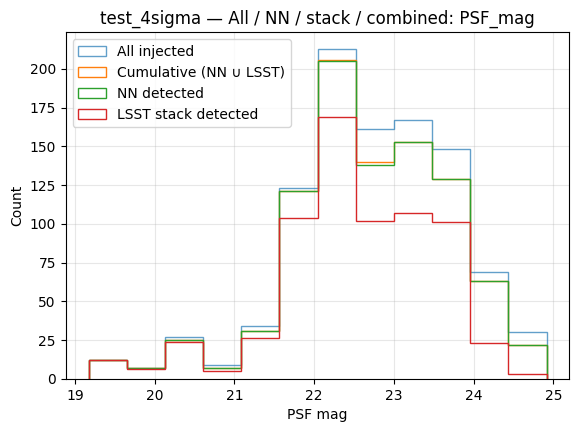

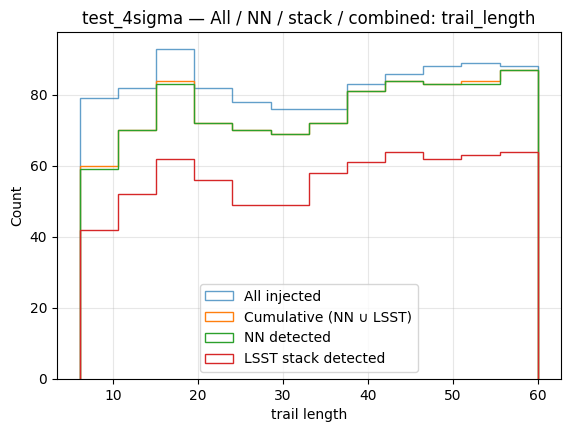

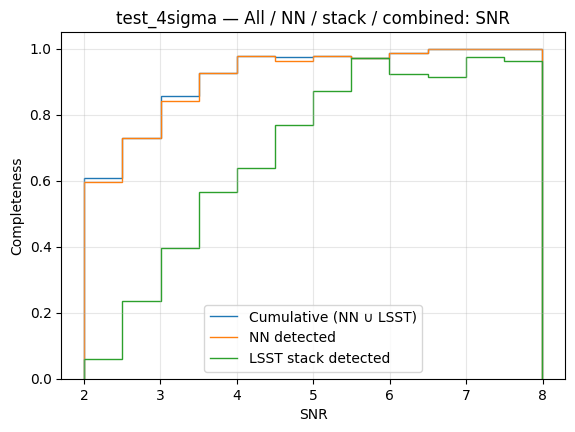

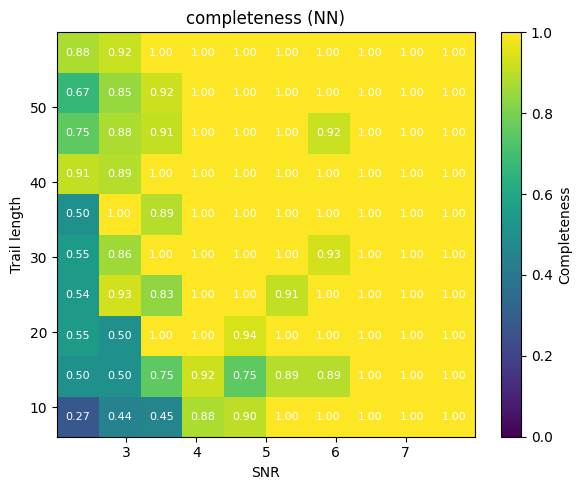

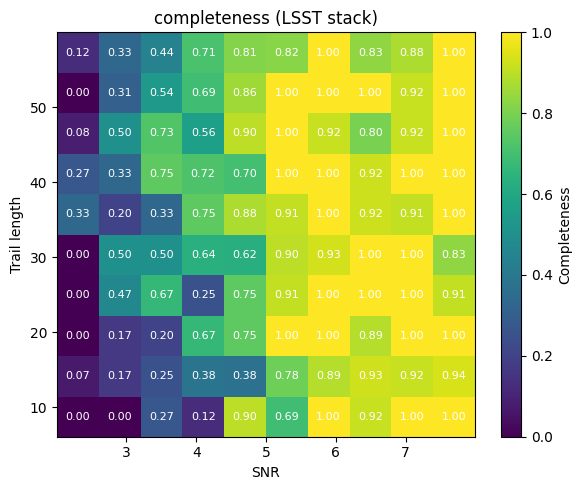

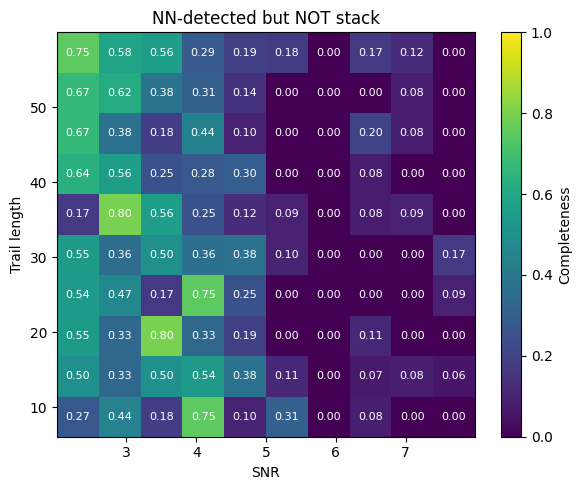

In [4]:
counts, t, pairs, cat = evaluate_set('test_4sigma')
show_confusion(counts, 'test_4sigma + NN — object-level')
row = compare_methods('test_4sigma', counts, t)
for field, kw in [('PSF_mag', {}), ('trail_length', {}), ('SNR', dict(xlim=[0,10], density=True))]:
    evals.plot_detect_hist(t, field, bins=12, title='test_4sigma — All / NN / stack / combined: '+field, **kw); plt.show()
evals.plot_completeness_2d(t, snr_bins=10, trail_bins=10, title='completeness (NN)'); plt.show()
evals.plot_completeness_2d(t, snr_bins=10, trail_bins=10, detected=t['stack_detection'].values, title='completeness (LSST stack)'); plt.show()
evals.plot_completeness_2d(t, snr_bins=10, trail_bins=10, detected=(~t['stack_detection'].values & t['nn_detected'].values.astype(bool)), title='NN-detected but NOT stack'); plt.show()

## test_3sigma

test_3sigma + NN — object-level
F1 Score: 0.0533, F2 Score: 0.1229
                 Predicted Negative  Predicted Positive
Actual Negative                <NA>               33227
Actual Positive                  62                 938




[test_3sigma] NN vs LSST-stack vs combined (n=1000 trails, 50 panels):
  LSST stack : recall=0.879 (879)   FP=142072 (2841.4/panel)
  v7+CNN     : recall=0.938 (938)   FP=33227 (664.5/panel)
  combined   : recall=0.955 (955)   NN recovers 76 stack-missed


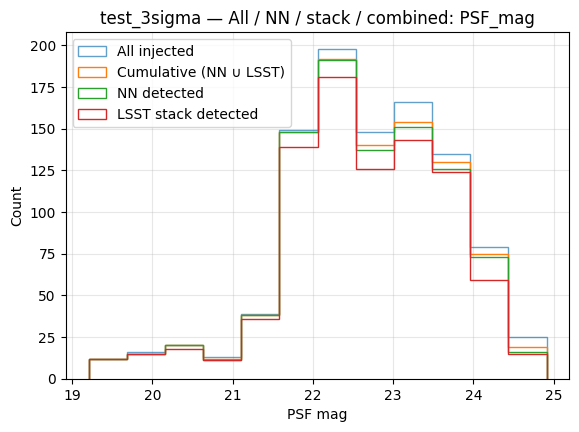

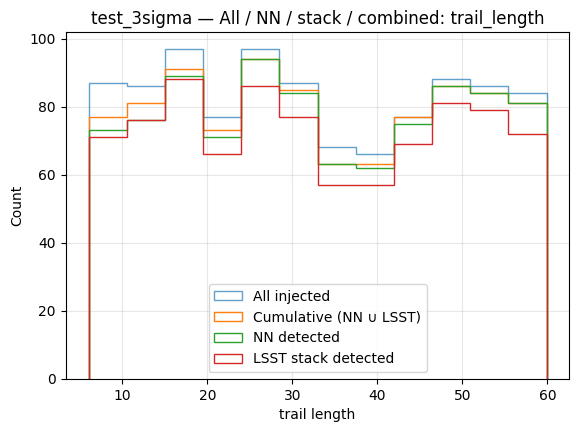

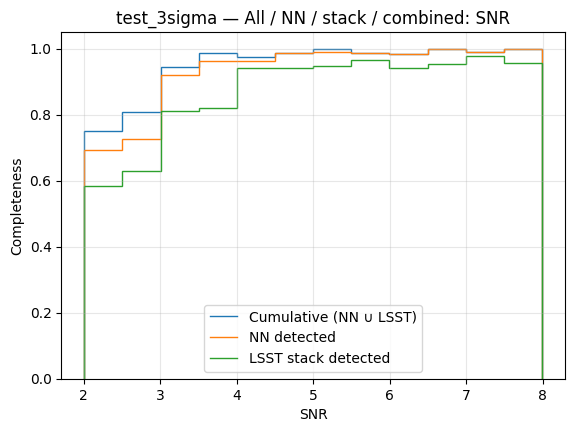

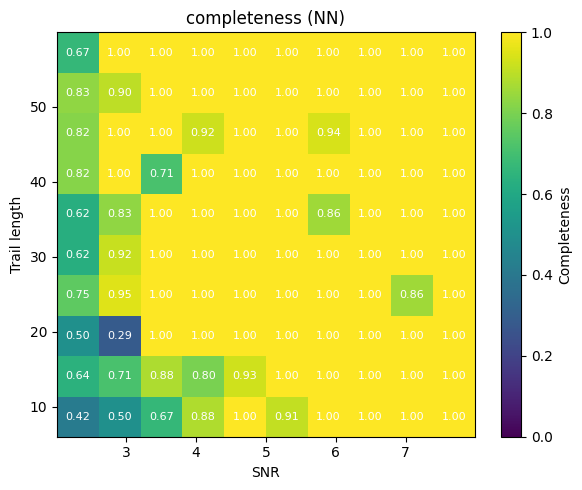

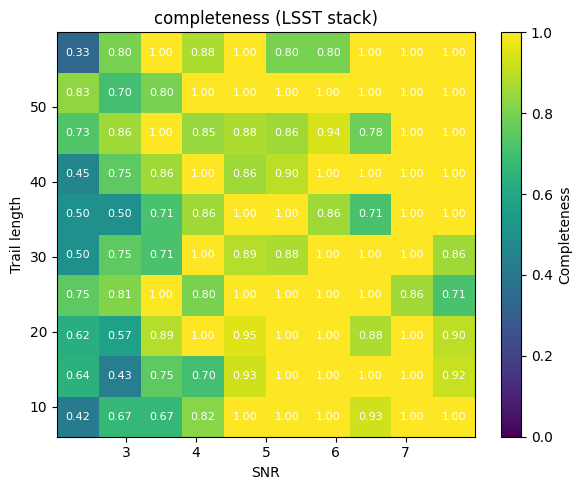

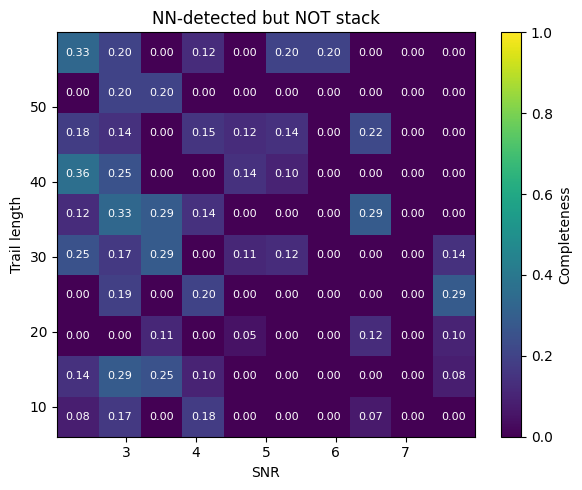

In [5]:
counts, t, pairs, cat = evaluate_set('test_3sigma')
show_confusion(counts, 'test_3sigma + NN — object-level')
row = compare_methods('test_3sigma', counts, t)
for field, kw in [('PSF_mag', {}), ('trail_length', {}), ('SNR', dict(xlim=[0,10], density=True))]:
    evals.plot_detect_hist(t, field, bins=12, title='test_3sigma — All / NN / stack / combined: '+field, **kw); plt.show()
evals.plot_completeness_2d(t, snr_bins=10, trail_bins=10, title='completeness (NN)'); plt.show()
evals.plot_completeness_2d(t, snr_bins=10, trail_bins=10, detected=t['stack_detection'].values, title='completeness (LSST stack)'); plt.show()
evals.plot_completeness_2d(t, snr_bins=10, trail_bins=10, detected=(~t['stack_detection'].values & t['nn_detected'].values.astype(bool)), title='NN-detected but NOT stack'); plt.show()

## Combined — cross-σ completeness comparison (5σ vs 5σ+NN vs 4σ vs 3σ)

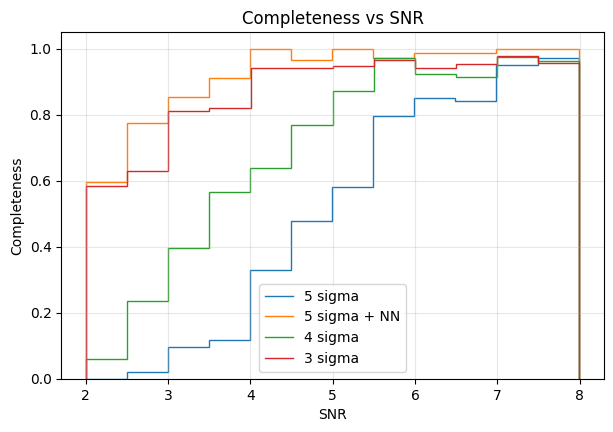

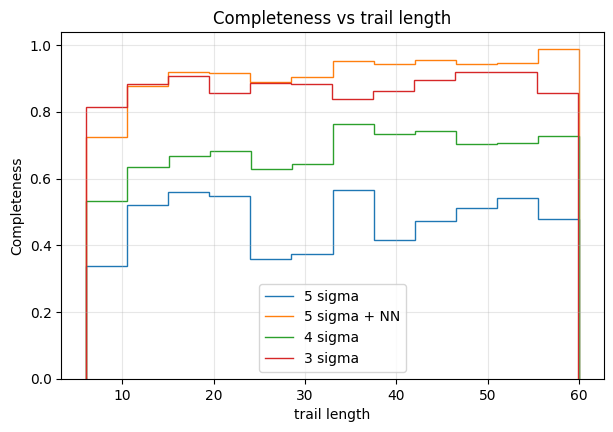

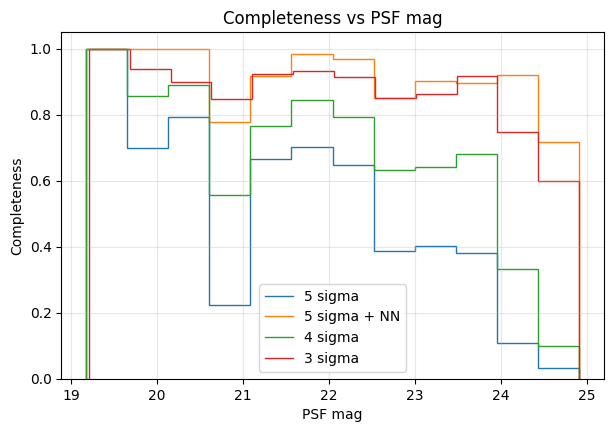

In [6]:
t5=evaluate_set('test_5sigma')[1]; t4=evaluate_set('test_4sigma')[1]; t3=evaluate_set('test_3sigma')[1]
# '5 sigma + NN' = 5sigma with stack OR NN (the combined detector); others are LSST-stack completeness
c5n=t5.copy(); c5n['stack_detection']=t5['stack_detection'].astype(bool) | t5['nn_detected'].astype(bool)
cats=[t5,c5n,t4,t3]; labels=['5 sigma','5 sigma + NN','4 sigma','3 sigma']
completeness_overlay(cats, labels, 'SNR', xlim=[0,10], title='Completeness vs SNR')
completeness_overlay(cats, labels, 'trail_length', title='Completeness vs trail length')
completeness_overlay(cats, labels, 'PSF_mag', title='Completeness vs PSF mag')

## Final summary — TP / FP / FN (LSST stack at 3σ/4σ/5σ vs 5σ + NN combined)

In [7]:
# Final table only: TP / FP / FN per detection configuration.
# 3/4/5 sigma = LSST stack at that threshold; '5 sigma + NN' = 5sigma stack OR v7+CNN   (combined).
rows = []
for name in ['test_3sigma', 'test_4sigma', 'test_5sigma']:
    counts, t, _, _ = evaluate_set(name)
    st = t['stack_detection'].astype(bool)
    rows.append({'config': name.replace('test_', '').replace('sigma', ' sigma'),
                 'TP': int(st.sum()), 'FP': stack_fp_count(name), 'FN': int((~st).sum())})
counts5, t5, _, _ = evaluate_set('test_5sigma')
comb = t5['stack_detection'].astype(bool) | t5['nn_detected'].astype(bool)
rows.append({'config': '5 sigma + NN', 'TP': int(comb.sum()),
             'FP': stack_fp_count('test_5sigma') + counts5['FP'], 'FN': int((~comb).sum())})
print(pd.DataFrame(rows)[['config', 'TP', 'FP', 'FN']].to_string(index=False))

      config  TP     FP  FN
     3 sigma 879 142072 121
     4 sigma 682  15029 318
     5 sigma 475   6405 525
5 sigma + NN 915  55746  85
